In [1]:
import pandas as pd

train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")

# Merge using building_id
data = train_values.merge(train_labels, on="building_id")

print(data.shape)
data.head()

(260601, 40)


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [2]:
data.drop(columns = "building_id", inplace = True)

In [3]:
columns = data.select_dtypes(include=["number"])

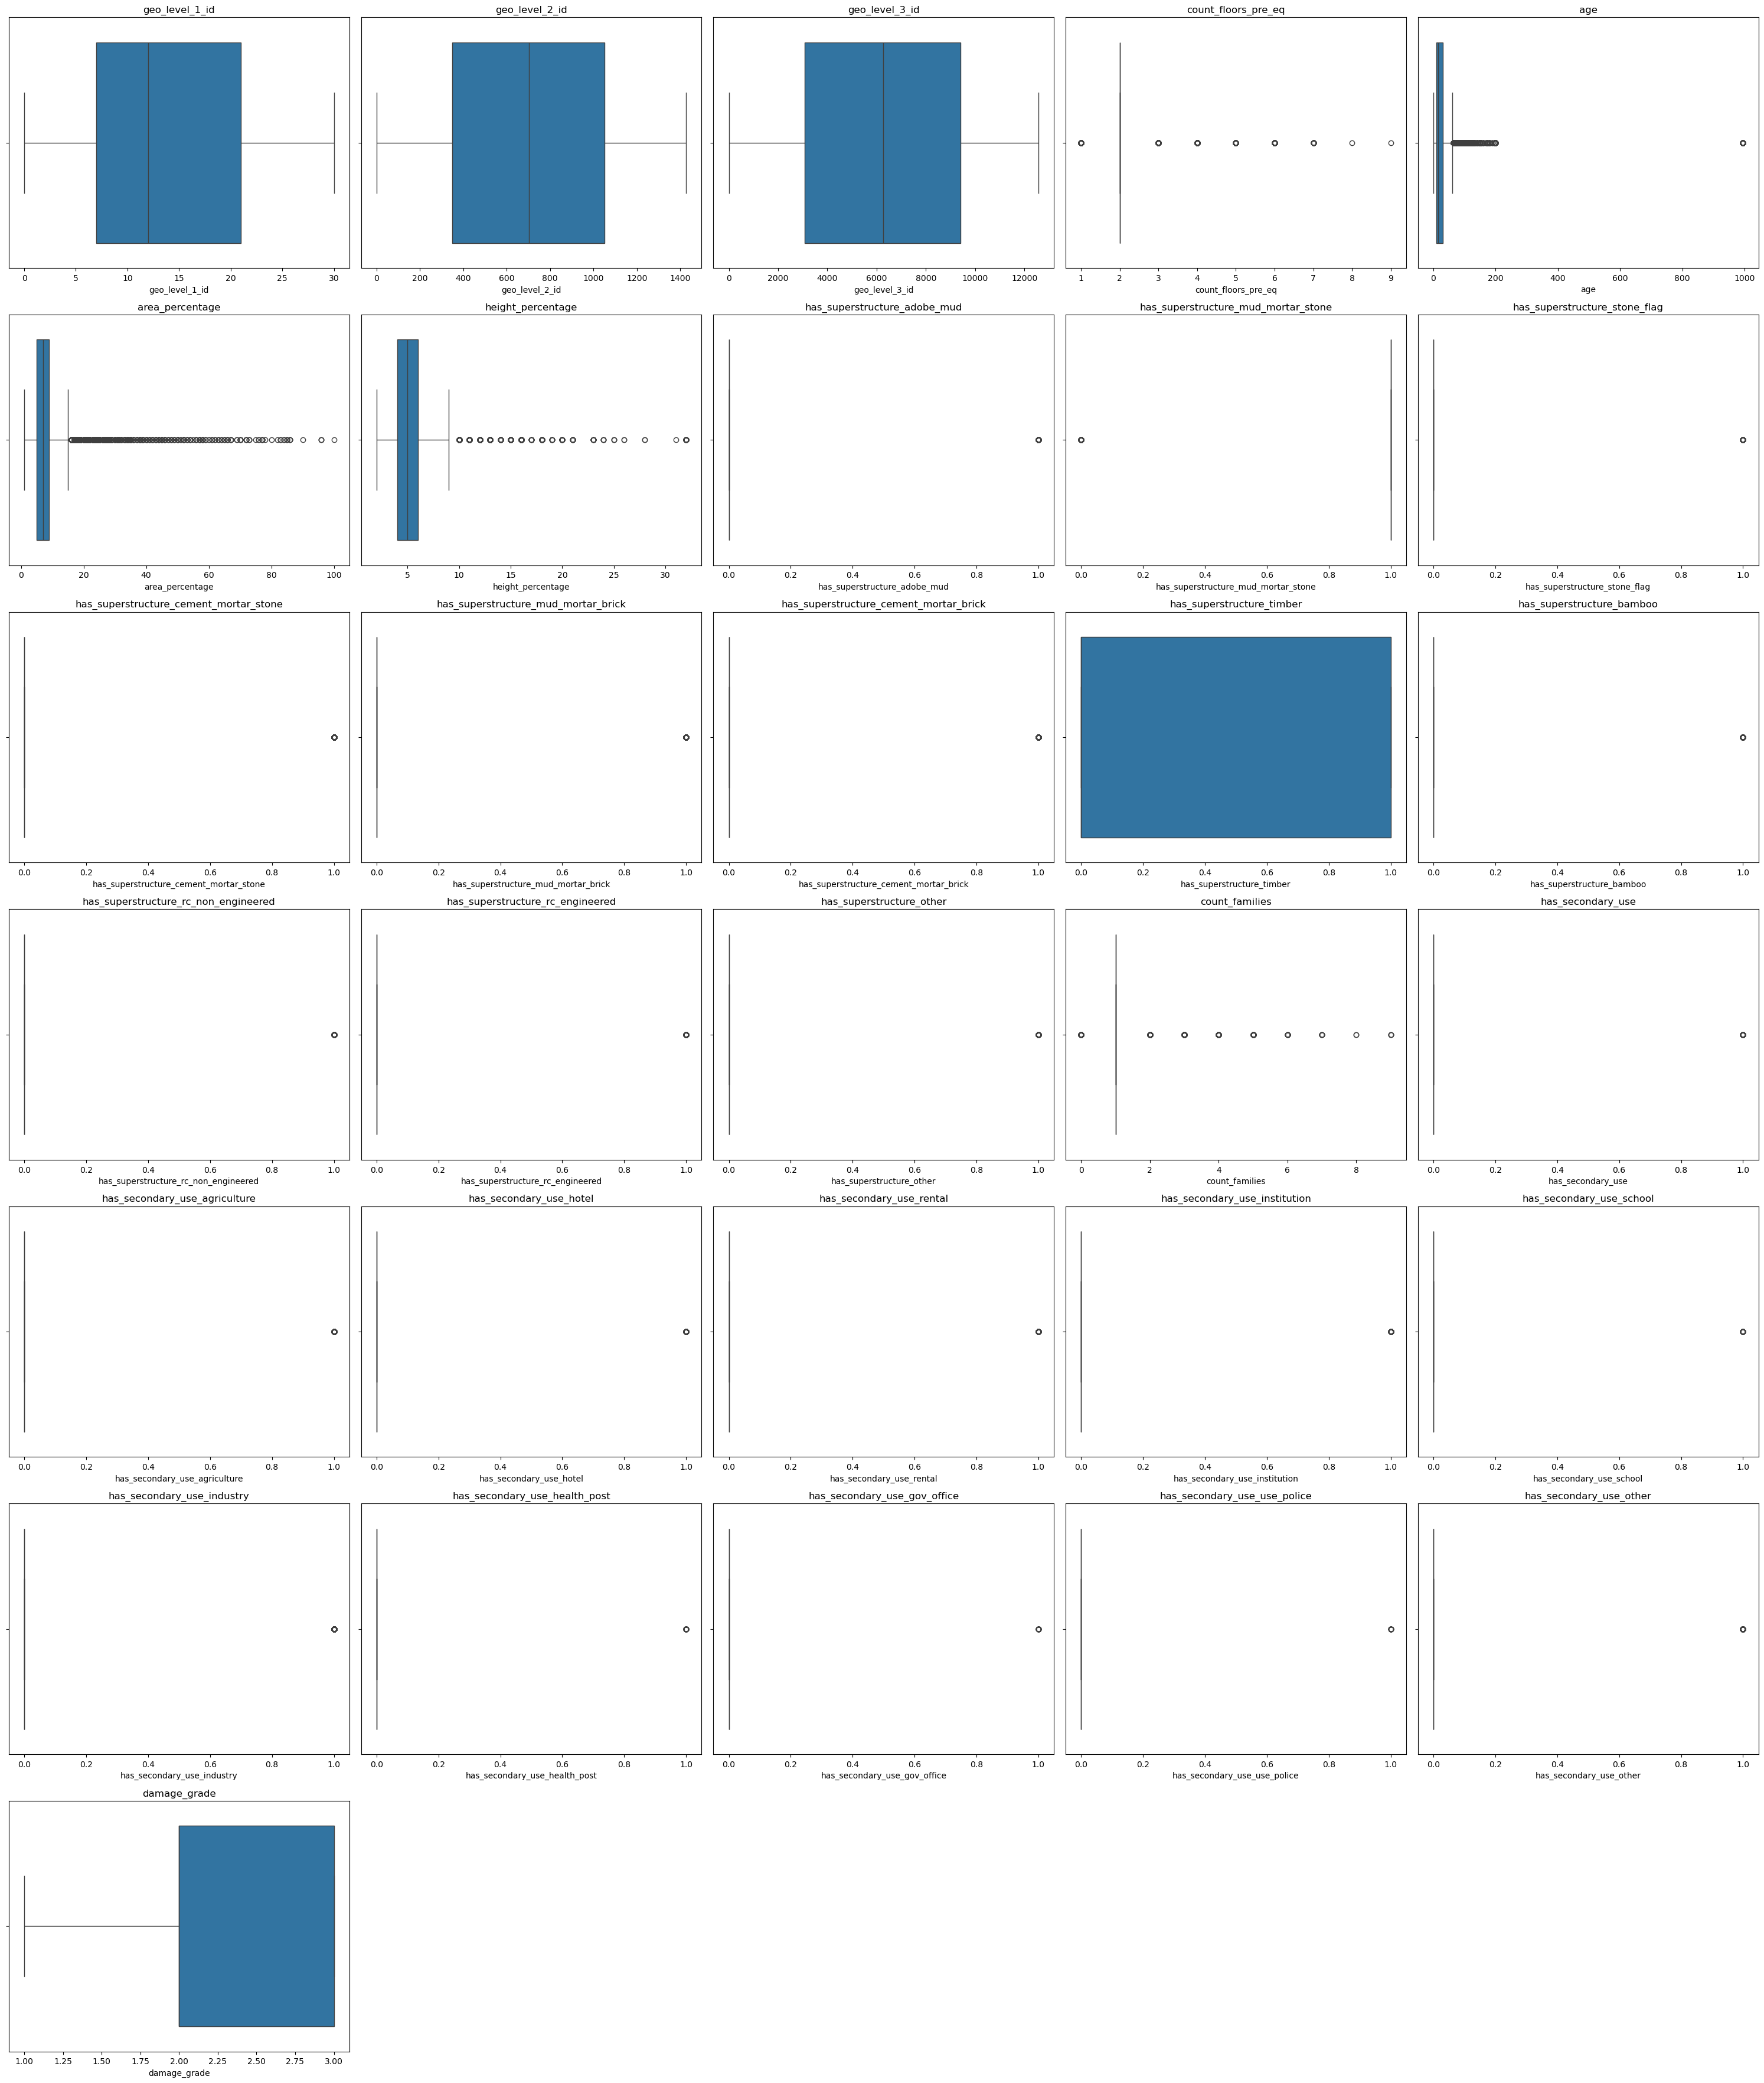

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include=["number"]).columns

plt.figure(figsize=(30, 40))

for i, col in enumerate(num_cols, 1):
    plt.subplot(8, 5, i)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [5]:
# Observation:
# Some numerical features contain outliers.

# Decision:
# I used the IQR method with clipping instead of removing rows.

# Reason:
# Removing rows may lead to loss of important information. Clipping reduces
# the impact of extreme values while keeping all observations in the dataset.

In [51]:
for col in columns:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5*iqr
    data[col] = data[col].clip(lower=lower, upper=upper)

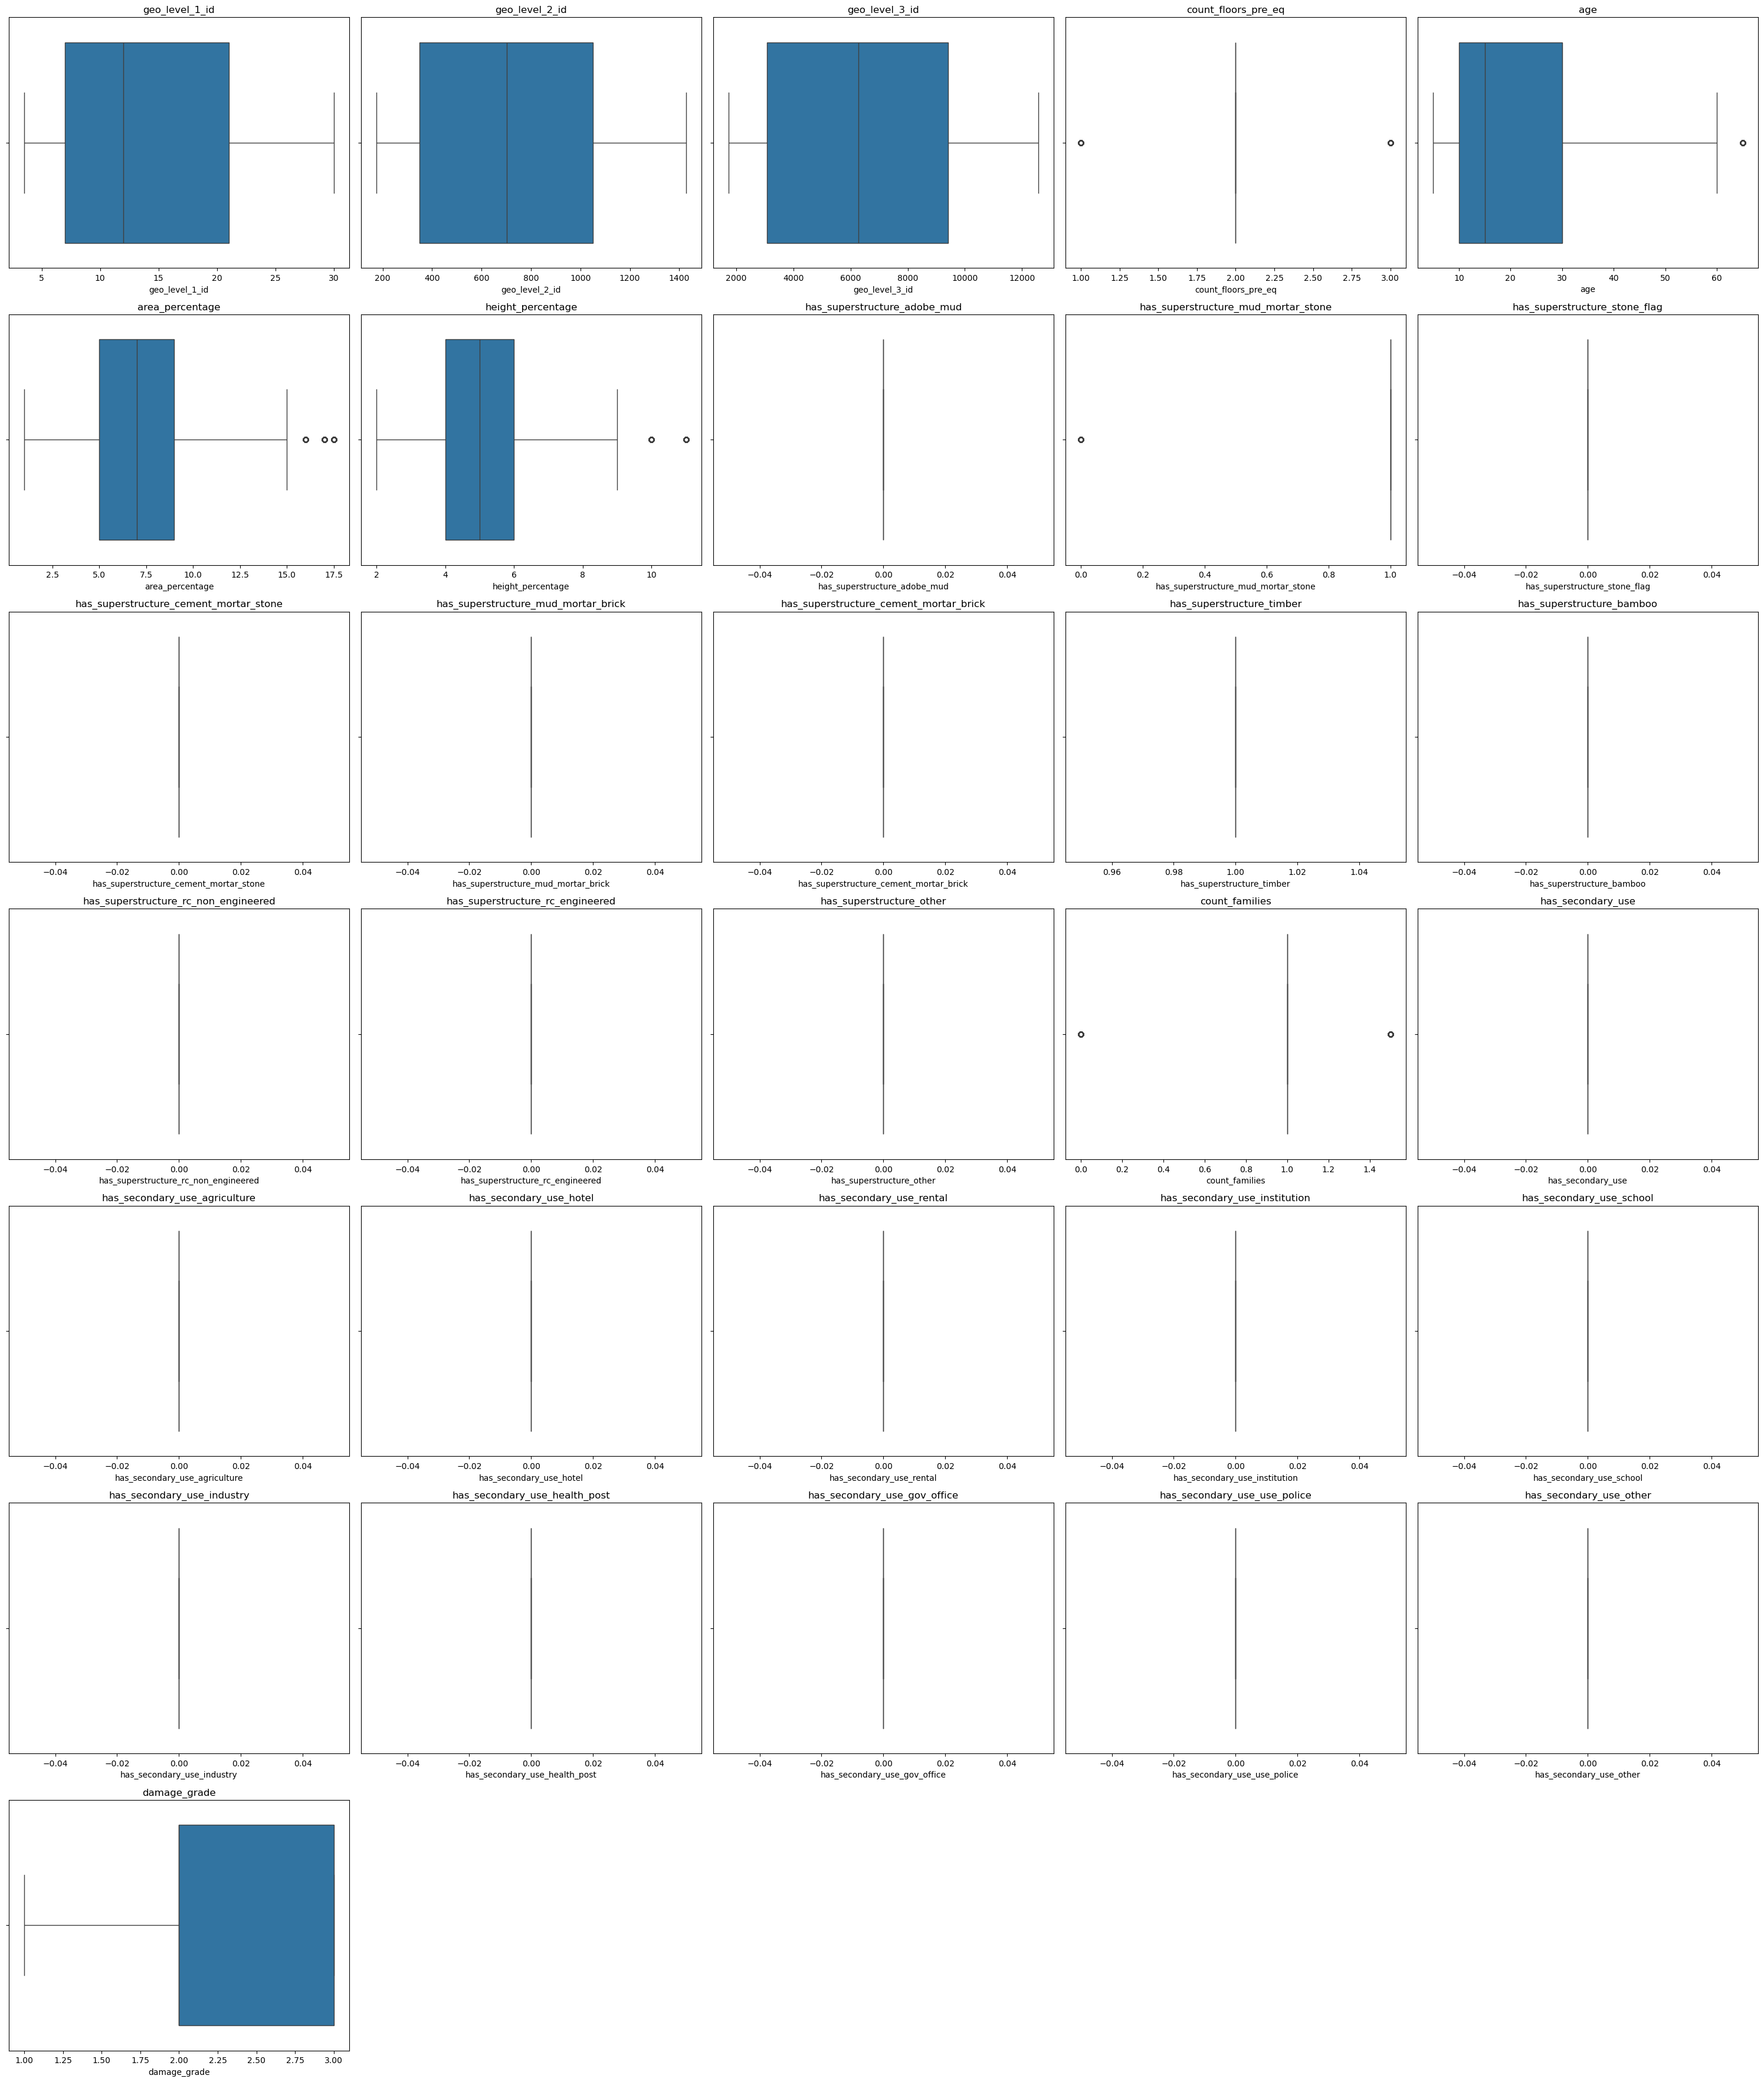

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = data.select_dtypes(include=["number"]).columns

plt.figure(figsize=(30, 40))

for i, col in enumerate(num_cols, 1):
    plt.subplot(8, 5, i)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [8]:
continuous_cols = [
    'age',
    'area_percentage',
    'height_percentage',
    'count_floors_pre_eq',
    'count_families'
]

data[continuous_cols].skew()

age                    1.190170
area_percentage        1.031625
height_percentage      0.576145
count_floors_pre_eq   -0.065674
count_families        -2.168851
dtype: float64

In [9]:
import numpy as np

data['age'] = np.log1p(data['age'])
data['area_percentage'] = np.log1p(data['area_percentage'])

In [10]:
# Observation:
# The age and area_percentage features were highly right-skewed.

# Decision:
# Applied log1p transformation.

# Reason:
# Log transformation reduces skewness, minimizes the effect of extreme values,
# and makes the feature distribution more balanced for model training.

In [11]:
continuous_cols = [
    'age',
    'area_percentage',
    'height_percentage',
    'count_floors_pre_eq',
    'count_families'
]

data[continuous_cols].skew()

age                    0.023280
area_percentage        0.025316
height_percentage      0.576145
count_floors_pre_eq   -0.065674
count_families        -2.168851
dtype: float64

In [12]:
print(data['count_families'].value_counts().sort_index())

count_families
0.0     20862
1.0    226115
1.5     13624
Name: count, dtype: int64


In [13]:
# count_families has high skewness, but I did not remove it because it has only
# 3 unique values (0, 1, and 1.5). It is a discrete feature, not a continuous feature.
# Log transformation is mainly used for continuous features with many different values.
# Applying log here would not improve the data or give the model any extra information,
# so I kept this feature as it is.

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   geo_level_1_id                          260601 non-null  float64
 1   geo_level_2_id                          260601 non-null  int64  
 2   geo_level_3_id                          260601 non-null  float64
 3   count_floors_pre_eq                     260601 non-null  int64  
 4   age                                     260601 non-null  float64
 5   area_percentage                         260601 non-null  float64
 6   height_percentage                       260601 non-null  int64  
 7   land_surface_condition                  260601 non-null  object 
 8   foundation_type                         260601 non-null  object 
 9   roof_type                               260601 non-null  object 
 10  ground_floor_type                       2606

In [43]:
# Observation:
# Checked the dataset for missing values using data.isnull().sum().
# No missing values were found in any column.

# Decision:
# No imputation step was required.

# Reason:
# Since the dataset was already clean, applying imputation would be
# unnecessary and could introduce noise instead of improving the data.

In [15]:
num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 31
Categorical columns: 8


In [16]:
for col in cat_cols:
    print(col.upper(), "COLUMN")
    print(data[col].unique())

LAND_SURFACE_CONDITION COLUMN
['t' 'o' 'n']
FOUNDATION_TYPE COLUMN
['r' 'w' 'i' 'u' 'h']
ROOF_TYPE COLUMN
['n' 'q' 'x']
GROUND_FLOOR_TYPE COLUMN
['f' 'x' 'v' 'z' 'm']
OTHER_FLOOR_TYPE COLUMN
['q' 'x' 'j' 's']
POSITION COLUMN
['t' 's' 'j' 'o']
PLAN_CONFIGURATION COLUMN
['d' 'u' 's' 'q' 'm' 'c' 'a' 'n' 'f' 'o']
LEGAL_OWNERSHIP_STATUS COLUMN
['v' 'a' 'r' 'w']


In [17]:
data = pd.get_dummies(data,
                      columns=cat_cols,
                      dtype=int)

In [18]:
# Observation:
# The dataset contains categorical features.

# Decision:
# Applied One-Hot Encoding using pd.get_dummies().

# Reason:
# Machine learning models cannot directly understand text values. One-Hot
# Encoding converts categorical features into numerical format.

In [19]:
train_data = data.drop(columns = "damage_grade")
test_data = data["damage_grade"]

In [20]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [21]:
from xgboost import XGBClassifier
X = data.drop("damage_grade", axis=1)
y = data["damage_grade"] - 1
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
# Observation:
# The dataset is ready for model training.

# Decision:
# Split the data into training and testing sets.

# Reason:
# The training set is used to train the model, while the testing set is used
# to evaluate how well the model performs on unseen data.

In [23]:
from xgboost import XGBClassifier

model = XGBClassifier()

model.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [24]:
# Decision:
# Trained an XGBoost Classifier.

# Reason:
# XGBoost is an efficient gradient boosting algorithm that handles both
# numerical and categorical features well after encoding. It is robust,
# reduces overfitting, and generally provides high accuracy on structured data.

In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import f1_score

print(f1_score(y_test, y_pred, average='weighted'))

0.7143433771513645


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort descending
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance.head(20)

,Feature,Importance
35,foundation_type_r,0.424769
43,ground_floor_type_v,0.113416
8,has_superstructure_mud_mortar_stone,0.052384
0,geo_level_1_id,0.052138
34,foundation_type_i,0.046164
47,other_floor_type_q,0.020816
40,roof_type_x,0.019139
33,foundation_type_h,0.015393
3,count_floors_pre_eq,0.012587
1,geo_level_2_id,0.012164


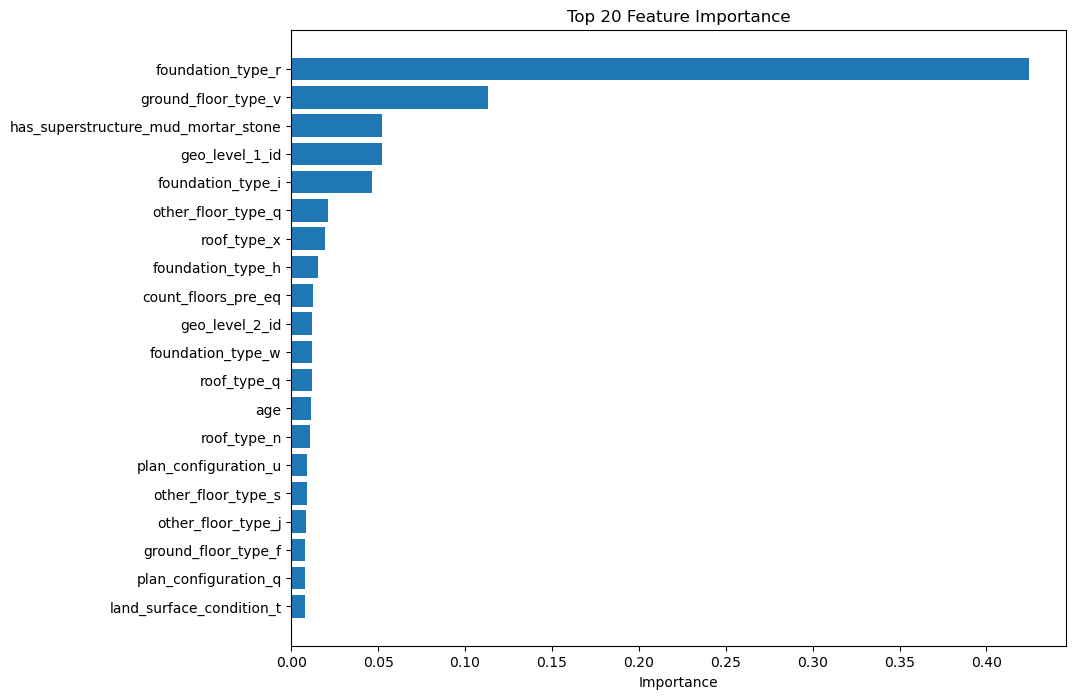

In [28]:
plt.figure(figsize=(10,8))

plt.barh(
    feature_importance['Feature'][:20],
    feature_importance['Importance'][:20]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 20 Feature Importance")
plt.show()

In [29]:
low_imp = feature_importance[
    feature_importance['Importance'] < 0.001
]

cols_to_drop = low_imp['Feature'].tolist()

X_new = X.drop(columns=cols_to_drop)

In [44]:
# Observation:
# After training the first XGBoost model, several features showed very low
# importance scores (less than 0.001), meaning they contributed almost
# nothing to the model's predictions.

# Decision:
# Dropped these low-importance features and retrained the model using
# only the more relevant features (X_new).

# Reason:
# Removing low-importance features reduces noise and dimensionality,
# which can improve model generalization, reduce overfitting, and
# speed up training without hurting performance.

In [30]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X_new,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax', 
    num_class=3,                
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Weighted F1 Score:",
      f1_score(y_test, y_pred, average='weighted'))

Weighted F1 Score: 0.7339623353970555


In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
model = RandomForestClassifier(
    n_estimators=1000,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import f1_score

print(f1_score(y_test, y_pred, average='weighted'))

0.676350892881469


In [45]:
# Decision:
# Trained a Random Forest Classifier as an additional ensemble model.

# Reason:
# Random Forest reduces overfitting by averaging predictions across many
# decision trees and handles non-linear relationships well, making it a
# good baseline ensemble model to compare against boosting models.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
model = LogisticRegression(max_iter=10000, random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [36]:
print("LOGISTIC REGRESSION MODEL")
print("F1_SCORE : ",f1_score(y_test,y_pred,average = "weighted"))

LOGISTIC REGRESSION MODEL
F1_SCORE :  0.531599565057954


In [46]:
# Observation:
# Logistic Regression is a linear model and is sensitive to feature scale,
# unlike tree-based models.

# Decision:
# Applied StandardScaler to scale features before training Logistic
# Regression.

# Reason:
# Without scaling, features with larger numeric ranges would dominate the
# other features, leading to poor performance.

In [37]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("DECISION TREE")
print(f1_score(y_test, y_pred, average='weighted'))

DECISION TREE
0.6559310484465252


In [47]:
# Decision:
# Trained a single Decision Tree Classifier as a simple baseline model.

# Reason:
# Used to compare against ensemble methods (Random Forest, XGBoost, GradientBoosting)

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
print("GRADIENT BOOSTING")
print(f1_score(y_test, y_pred, average='weighted'))

GRADIENT BOOSTING
0.716050613544642


In [53]:
# Increasing in the number of d_trees will not give better performance for this data. So, it's better to stop here.

In [54]:
# Decision:
# Trained a Gradient Boosting Classifier.

# Reason:
# Gradient Boosting builds trees sequentially, where each tree corrects
# errors made by the previous one, often improving accuracy over a single
# decision tree or random forest on structured/tabular data.

In [55]:
# Note:
# SVM and KNN were not good for this dataset because the dataset is too large (260k rows)
# and has too many columns after encoding, which makes both very slow
# and not a good fit here. Tree-based models work better for this.

In [64]:
# Comparison of multiple models

comparison = pd.DataFrame({"Model": ["Logistic Regression","Decision Tree", "Random Forest", "Gradient Boosting", "XGBoost"],
"F1-Score":[0.53,0.65,0.67,0.71,0.73]})
comparison = comparison.sort_values(by="F1-Score", ascending=False).reset_index(drop = True)

comparison

,Model,F1-Score
0,XGBoost,0.73
1,Gradient Boosting,0.71
2,Random Forest,0.67
3,Decision Tree,0.65
4,Logistic Regression,0.53


In [73]:
# Model Selection

# XGBoost is selected as the final model because it achieved the highest F1-Score (0.73) among all evaluated models.
# Now will perform the Hyperparamter tuning for XGBoost using RandomizedSearchCV to get better performance.

In [74]:
# Hyperparamter Tuning

In [75]:
from sklearn.model_selection import RandomizedSearchCV

In [78]:
xgb = XGBClassifier(
    objective='multi:softmax',
    random_state=42,
    eval_metric='mlogloss',
    num_class=3
)

param_dist = {
    'n_estimators': [600, 800, 1000],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test)

print("Tuned XGBoost F1-Score:")
print(f1_score(y_test, y_pred, average='weighted'))

print("Best Parameters:")
print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Tuned XGBoost F1-Score:
0.7327538965725657
Best Parameters:
{'subsample': 0.8, 'n_estimators': 600, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [79]:
# Observation:
# Hyperparameter tuning gave little or no improvement.

# Decision:
# The original XGBoost model is selected as the final model.

# Reason:
# The original model already achieved good performance,
# and tuning did not significantly improve the F1-score.

In [80]:
# FINAL MODEL SELECTION
# XGBoost is selected as the final model because it achieved the highest Weighted F1-score.
# It is the most suitable model for predicting earthquake damage levels.

In [81]:
# Conclusion:
# Different machine learning models were trained and compared.
# XGBoost achieved the highest Weighted F1-Score and was selected
# as the final model for predicting earthquake damage levels.

In [82]:
# Challenges:
# - Large dataset increased training time.
# - Hyperparameter tuning required additional computation.

In [83]:
# Future Improvements
# Try LightGBM and CatBoost.
# Explore additional feature engineering.
# Use cross-validation with more folds for further evaluation.

In [84]:
import pickle

with open("xgboost_model.pkl","wb") as file:
    pickle.dump(xgb, file)

print("Model saved successfully!")

Model saved successfully!
